### Предобработка данных

Размер исходного датасета: (21613, 16)
После удаления некорректных значений: (21597, 16)

Анализ выбросов по Z-score:


,mean,std,max_abs_z,outliers_count,outliers_percent
price,540202.919757,367125.231146,19.502329,406,1.88
sqft_living,2080.321850,918.084869,12.482156,248,1.15
sqft_lot,15099.408760,41411.678105,39.512033,346,1.60
sqft_above,1788.596842,827.740597,9.207478,253,1.17
sqft_living15,1986.620318,685.214608,6.163587,236,1.09
sqft_lot15,12758.283512,27273.810503,31.474946,363,1.68


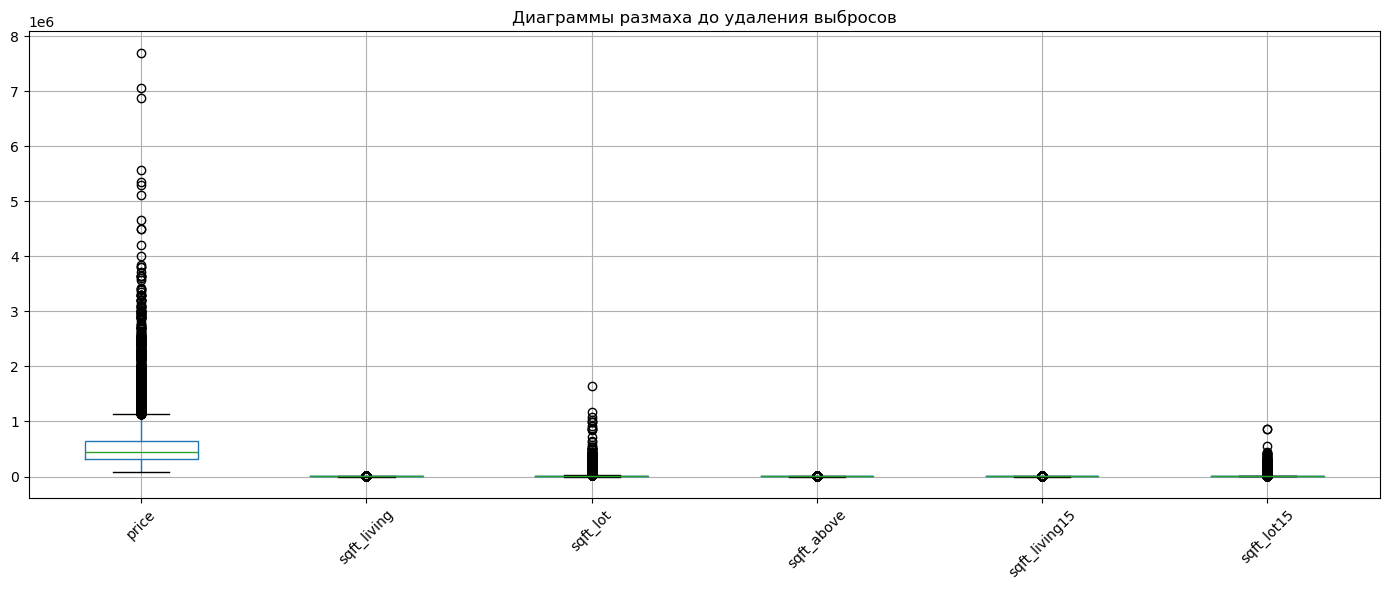

Размер до удаления выбросов: (21597, 16)
Размер после удаления выбросов: (20471, 16)
Удалено строк: 1126


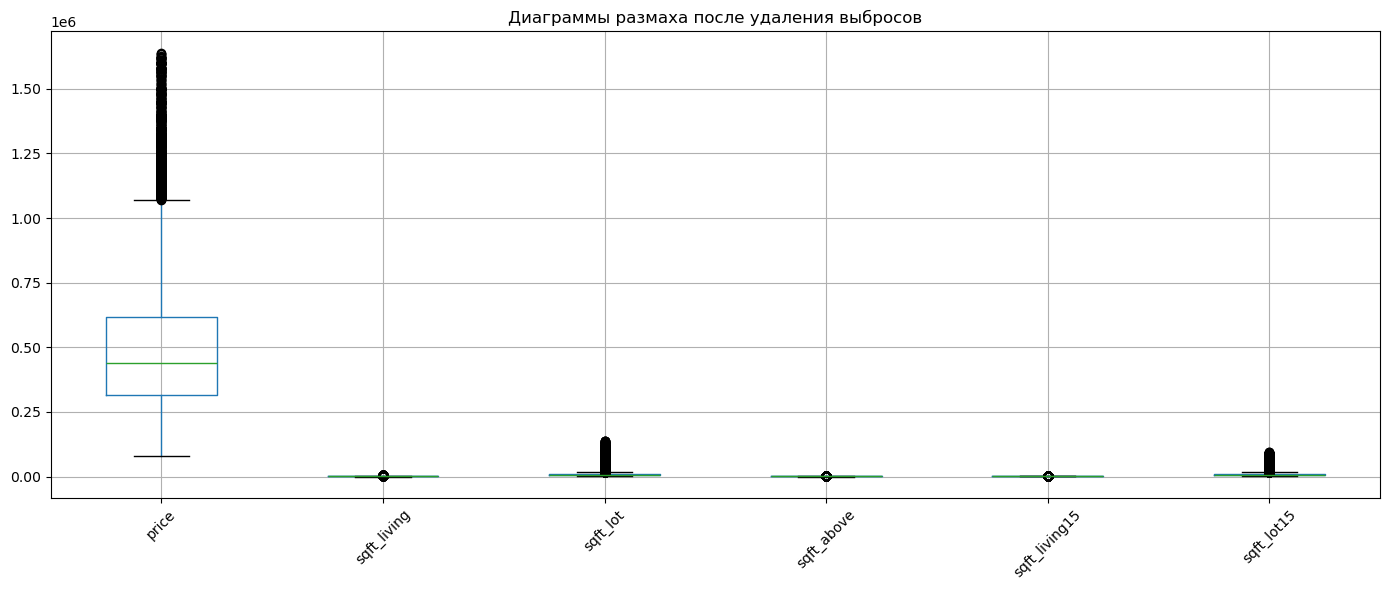

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = pd.read_csv("kc_house_data.csv", parse_dates=['date'])


data.drop(['id', 'date', 'sqft_basement', 'lat', 'long'], axis=1, inplace=True)

print("Размер исходного датасета:", data.shape)


data = data[(data['bedrooms'] > 0) & (data['bathrooms'] > 0)].copy()

print("После удаления некорректных значений:", data.shape)

# Признаки, по которым ищем выбросы
# Берем количественные признаки, для которых Z-score уместен
outlier_cols = [
    'price',
    'sqft_living',
    'sqft_lot',
    'sqft_above',
    'sqft_living15',
    'sqft_lot15'
]


z_scores = ((data[outlier_cols] - data[outlier_cols].mean()) / data[outlier_cols].std(ddof=0)).abs()

# Порог для выбросов
threshold = 3

# Таблица анализа выбросов
outliers_summary = pd.DataFrame({
    'mean': data[outlier_cols].mean(),
    'std': data[outlier_cols].std(ddof=0),
    'max_abs_z': z_scores.max(),
    'outliers_count': (z_scores > threshold).sum(),
    'outliers_percent': ((z_scores > threshold).mean() * 100).round(2)
})

print("\nАнализ выбросов по Z-score:")
display(outliers_summary)

# Визуализация до удаления выбросов
plt.figure(figsize=(14, 6))
data[outlier_cols].boxplot(rot=45)
plt.title("Диаграммы размаха до удаления выбросов")
plt.tight_layout()
plt.show()

# Удаление строк по признаку |Z| > 3
rows_without_outliers = (z_scores <= threshold).all(axis=1)
clean_data = data[rows_without_outliers].copy()

print("Размер до удаления выбросов:", data.shape)
print("Размер после удаления выбросов:", clean_data.shape)
print("Удалено строк:", data.shape[0] - clean_data.shape[0])

# Визуализация после удаления выбросов
plt.figure(figsize=(14, 6))
clean_data[outlier_cols].boxplot(rot=45)
plt.title("Диаграммы размаха после удаления выбросов")
plt.tight_layout()
plt.show()

Анализ выбросов выполнен с использованием Z-score. Для каждого количественного признака было вычислено стандартизованное отклонение значения от среднего. Наблюдения, для которых абсолютное значение Z-score превышало 3, рассматривались как выбросы и удалялись из выборки. До и после очистки были построены диаграммы размаха, позволяющие визуально оценить результат удаления выбросов.

In [2]:

df = clean_data.copy()

# Дополнительно приводим возможные "пустые" строки к NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Анализ пропусков
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
}).sort_values(by='missing_count', ascending=False)

print("Анализ пропусков:")
display(missing_summary)

print("Общее количество пропусков в таблице:", df.isnull().sum().sum())


Анализ пропусков:


,missing_count,missing_percent
price,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
sqft_living,0,0.0
sqft_lot,0,0.0
floors,0,0.0
waterfront,0,0.0
view,0,0.0
condition,0,0.0
grade,0,0.0


Общее количество пропусков в таблице: 0


Анализ показал отсутствие пропущенных значений в исследуемом наборе данных, поэтому дополнительное восстановление пропусков не потребовалось.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Разделяем признаки и целевую переменную
X = df.drop(columns='price')
y = df['price']

# Категориальные признаки, которые нужно бинаризовать
categorical_cols = [col for col in ['floors', 'view', 'condition', 'grade', 'bedrooms', 'bathrooms', 'zipcode'] if col in X.columns]

# Числовые признаки для стандартизации определяем сразу до dummy
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Преобразуем категориальные признаки в dummy-переменные
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

# Делим выборку
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=60
)

# Стандартизация только исходных числовых признаков
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Сохраняем итоговые таблицы
train_data_scaled = X_train.assign(price=y_train.values)
test_data_scaled = X_test.assign(price=y_test.values)

train_data_scaled.to_csv("kc_house_train_scaled.csv", index=False)
test_data_scaled.to_csv("kc_house_test_scaled.csv", index=False)

print("Готово. Данные стандартизированы.")
print("Стандартизированные признаки:", numeric_cols)

Готово. Данные стандартизированы.
Стандартизированные признаки: ['sqft_living', 'sqft_lot', 'waterfront', 'sqft_above', 'yr_built', 'yr_renovated', 'sqft_living15', 'sqft_lot15']


Стандартизация данных выполнена методом Z-нормализации с использованием `StandardScaler` из библиотеки Scikit-learn. Для каждого количественного признака значение было преобразовано по формуле: из значения вычиталось среднее и результат делился на стандартное отклонение. Категориальные признаки стандартизации не подвергались, так как далее они преобразуются в бинарные переменные. Параметры стандартизации вычислялись только на обучающей выборке, после чего применялись к тестовой выборке.

г) Обсуждение возможности выделения характерных признаков

Для повышения качества модели в задаче прогнозирования стоимости недвижимости можно выделить дополнительные характерные признаки на основе исходных данных.

В рассматриваемом наборе данных целесообразно использовать следующие производные признаки:
- возраст дома: разность между текущим годом и годом постройки (`house_age`);
- признак ремонта: наличие факта ремонта (`is_renovated`);
- возраст ремонта: разность между текущим годом и годом последнего ремонта (`renovation_age`);
- общая полезность расположения: комбинация признаков `waterfront`, `view` и `zipcode`;
- отношение жилой площади к площади участка;
- цену за квадратный метр, однако данный признак нельзя использовать при обучении модели, так как он рассчитывается через целевую переменную `price` и приводит к утечке данных.

Наиболее полезными для данной задачи являются признаки, отражающие физические характеристики объекта, его состояние и местоположение. В частности, признаки возраста дома, факта ремонта и территориальной принадлежности могут улучшить качество прогноза.

В рамках данной работы feature extraction возможен, однако должен выполняться только для признаков, не содержащих информации из целевой переменной. Поэтому допустимо создавать признаки на основе площади, года постройки, ремонта и местоположения, но недопустимо использовать производные показатели, напрямую зависящие от цены объекта.

In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# 1. Разделяем признаки и целевую переменную
# =========================

X = df.drop(columns='price')
y = df['price']

# =========================
# 2. Категориальные признаки, которые нужно бинаризовать
# =========================

categorical_cols = ['floors', 'view', 'condition', 'grade', 'bedrooms', 'bathrooms', 'zipcode']
categorical_cols = [col for col in categorical_cols if col in X.columns]

# =========================
# 3. Числовые признаки для стандартизации
# =========================

numeric_cols = [col for col in X.columns if col not in categorical_cols]

# =========================
# 4. Преобразуем категориальные признаки в dummy-переменные
# =========================

X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

# Чтобы названия были как в методичке: floors#1.0, floors#1.5 и т.д.
X.columns = [col.replace('_', '#') if col.startswith('floors_') else col for col in X.columns]

# =========================
# 5. Делим выборку
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=60
)

# =========================
# 6. Стандартизация только исходных числовых признаков
# =========================

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# =========================
# 7. Сохраняем итоговые таблицы
# =========================

train_data_scaled = X_train.assign(price=y_train.values)
test_data_scaled = X_test.assign(price=y_test.values)

train_data_scaled.to_csv("kc_house_train_scaled.csv", index=False)
test_data_scaled.to_csv("kc_house_test_scaled.csv", index=False)

print("Готово. Данные стандартизированы.")
print("Стандартизированные признаки:", numeric_cols)

# =========================
# 8. Обучение моделей
# =========================

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

ridge_model = Ridge(alpha=3)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=120, max_iter=10000)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

# =========================
# 9. Оценка качества моделей
# =========================

quality_table = pd.DataFrame({
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ],
    'R²': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
}, index=[
    'Линейная регрессия',
    'Гребневая регрессия (α = 3)',
    'Лассо (α = 120)'
]).round(4)

print('Качество регрессии:')
display(quality_table)

# =========================
# 10. Таблица коэффициентов только по нужным параметрам
# =========================

required_features = [
    'sqft_living',
    'sqft_lot',
    'waterfront',
    'sqft_above',
    'yr_built',
    'yr_renovated',
    'sqft_living15',
    'sqft_lot15',
    'floors#1.0',
    'floors#1.5',
    'floors#2.0',
    'floors#2.5',
    'floors#3.0',
    'floors#3.5'
]

coef_table = pd.DataFrame({
    'Линейная регрессия': linear_model.coef_,
    'Гребневая регрессия (α = 3)': ridge_model.coef_,
    'Лассо (α = 120)': lasso_model.coef_
}, index=X_train.columns)

coef_table_filtered = coef_table.loc[
    [col for col in required_features if col in coef_table.index]
].round(4)

print('Коэффициенты регрессии:')
display(coef_table_filtered)

# =========================
# 11. Значимые и незначимые коэффициенты линейной регрессии
# =========================

X_train_sm = sm.add_constant(X_train).astype(float)
y_train_sm = y_train.astype(float)

ols_model = sm.OLS(y_train_sm, X_train_sm).fit()

significance_table = pd.DataFrame({
    'factor': ols_model.params.index,
    'coef': ols_model.params.values,
    'p_value': ols_model.pvalues.values
})

significance_table = significance_table[significance_table['factor'] != 'const'].copy()
significance_table = significance_table[significance_table['factor'].isin(required_features)].copy()

alpha = 0.05
significance_table['significance'] = np.where(
    significance_table['p_value'] < alpha,
    'Значимый',
    'Незначимый'
)

significance_table = significance_table.sort_values(by='p_value').round(6)

print('Значимость коэффициентов линейной регрессии:')
display(significance_table)

# =========================
# 12. Отдельно значимые и незначимые коэффициенты
# =========================

significant_features = significance_table[significance_table['significance'] == 'Значимый']
insignificant_features = significance_table[significance_table['significance'] == 'Незначимый']

print('Значимые коэффициенты:')
display(significant_features)

print('Незначимые коэффициенты:')
display(insignificant_features)

# =========================
# 13. Сохранение результатов
# =========================

quality_table.to_csv('quality_table.csv', encoding='utf-8-sig')
coef_table_filtered.to_csv('coef_table_filtered.csv', encoding='utf-8-sig')
significance_table.to_csv('significance_table.csv', index=False, encoding='utf-8-sig')

print('Готово. Все таблицы рассчитаны и сохранены.')

Готово. Данные стандартизированы.
Стандартизированные признаки: ['sqft_living', 'sqft_lot', 'waterfront', 'sqft_above', 'yr_built', 'yr_renovated', 'sqft_living15', 'sqft_lot15']
Качество регрессии:


,RMSE,R²
Линейная регрессия,102159.1269,0.8380
Гребневая регрессия (α = 3),102565.1232,0.8367
Лассо (α = 120),103779.7631,0.8328


Коэффициенты регрессии:


,Линейная регрессия,Гребневая регрессия (α = 3),Лассо (α = 120)
sqft_living,62408.6468,63150.6253,69115.1453
sqft_lot,13975.2937,13580.2002,11868.0685
waterfront,14775.1348,14719.0072,14338.6281
sqft_above,26536.7018,25183.4039,20148.9164
yr_built,-9062.7504,-11004.4526,-14093.1685
yr_renovated,10242.8237,10111.7406,10149.5385
sqft_living15,15352.1082,16402.0133,18595.6401
sqft_lot15,-8157.7557,-8545.3363,-9093.6411
floors#1.0,33413.1056,24580.3568,0.0000
floors#1.5,35488.0730,27123.1168,3770.8554


Значимость коэффициентов линейной регрессии:


...

Значимые коэффициенты:


,factor,coef,p_value,significance
1,sqft_living,62410.648649,0.0,Значимый
3,waterfront,14779.472181,0.0,Значимый
4,sqft_above,26539.370934,0.0,Значимый
6,yr_renovated,10247.161034,0.0,Значимый
7,sqft_living15,15355.444584,0.0,Значимый
2,sqft_lot,13974.960105,0.0,Значимый
5,yr_built,-9047.069191,0.0,Значимый
8,sqft_lot15,-8160.758472,0.0,Значимый


Незначимые коэффициенты:


,factor,coef,p_value,significance
14,floors#3.5,-1.551733e+15,0.638214,Незначимый
13,floors#3.0,-1.551733e+15,0.638214,Незначимый
11,floors#2.0,-1.551733e+15,0.638214,Незначимый
12,floors#2.5,-1.551733e+15,0.638214,Незначимый
9,floors#1.0,-1.551733e+15,0.638214,Незначимый
10,floors#1.5,-1.551733e+15,0.638214,Незначимый


Готово. Все таблицы рассчитаны и сохранены.


Качество моделей оценивалось по показателям RMSE и R². Значение RMSE показывает среднюю величину ошибки прогноза стоимости недвижимости: чем оно меньше, тем точнее модель. Коэффициент детерминации R² отражает долю вариации целевой переменной, объясняемую моделью: чем ближе значение к 1, тем лучше качество аппроксимации.
По полученным результатам наилучшее качество показала модель линейной регрессии: RMSE = 102159.13, R² = 0.8380. Это означает, что модель объясняет около 83.8% изменчивости стоимости недвижимости, а средняя ошибка прогноза составляет около 102 тыс. денежных единиц. Модели гребневой регрессии и лассо показали близкие, но несколько худшие результаты.